# Chapter 6 — Portfolio Construction: Efficient Frontier and Risk Parity

This notebook is the runnable companion to the chapter README. It walks the same three-philosophy structure: **minimize risk** (GMV / efficient frontier), **maximize risk-adjusted return** (tangency / max-Sharpe + the Capital Market Line), and **allocate risk equally** (risk parity). The §5 instability lesson is the load-bearing caveat woven through.

Same 8-ticker basket as Chapters 3–5; same 20-year window; same `^IRX`-derived risk-free rate. No new packages — just `numpy`, `pandas`, `matplotlib`, `yfinance`, and `scipy.optimize.minimize`.

## What we mean by "the best" portfolio

| Construction philosophy | What it optimizes | Inputs needed |
|---|---|---|
| **Minimize risk** — GMV, the efficient frontier | Variance (or variance subject to a return target) | Σ only for GMV; μ + Σ for the frontier |
| **Maximize risk-adjusted return** — tangency / max-Sharpe | Sharpe ratio | μ, Σ, *r<sub>f</sub>* |
| **Allocate risk equally** — risk parity | Risk-contribution dispersion (drives all RC equal) | Σ only — *no μ* |

Each section below adds an input. §3 uses Σ. §4 adds μ and *r<sub>f</sub>*. §5 questions whether to trust μ at all. §6 stops using μ.

## 1. Setup

Imports, the 8-ticker basket, log returns, and the risk-free rate. Same as Chapter 5 — no new dependencies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

np.random.seed(42)
pd.options.display.float_format = "{:.4f}".format

TICKERS = ["SPY", "TLT", "GLD", "XLK", "XLF", "XLE", "XLV", "XLU"]

prices = yf.download(TICKERS, period="20y", auto_adjust=True, progress=False)["Close"]
prices = prices[TICKERS].dropna()
log_returns = np.log(prices).diff().dropna()

N, K = log_returns.shape
print(f"N = {N} trading days, K = {K} assets")
print(f"date range: {log_returns.index[0].date()}  →  {log_returns.index[-1].date()}")

N = 5030 trading days, K = 8 assets
date range: 2006-05-08  →  2026-05-05


In [2]:
# ^IRX is the annualized 13-week T-bill yield, quoted in percent.
# Per Ch5: divide by 100 (% → fraction), divide by 252 (annualized → per-day).
irx = yf.download("^IRX", period="20y", progress=False)["Close"].dropna()
rf_daily = (irx / 100.0 / 252.0).reindex(log_returns.index).ffill().bfill()
rf_daily = rf_daily.iloc[:, 0] if hasattr(rf_daily, "columns") else rf_daily

rf_ann_avg = float(rf_daily.mean() * 252)
print(f"avg annualized r_f over the window: {rf_ann_avg:.4%}")

avg annualized r_f over the window: 1.6061%


### Annualized μ̂ and Σ̂ — and a James-Stein recheck

We need three inputs for the optimizations: the annualized mean vector **μ̂**, the annualized covariance matrix **Σ̂**, and a single annualized risk-free rate (computed above).

Per Ch4 §3, we also build a **James-Stein-shrunk** version of μ̂. Heads up: at this sample size (N ≈ 5,000 daily obs) the shrinkage is *very* mild — the JS factor here is ≈ 0.99, in stark contrast to Ch4's outcome of ≈ 0 (total shrinkage). The README explains why: JS depends on the dispersion-vs-noise ratio, and at large N the SE-of-mean has shrunk faster than the cross-sectional dispersion has. Shrinkage barely pulls. **That is itself a useful lesson** — JS isn't a fixed multiplier.

In [3]:
# Annualized inputs.
mu_raw = log_returns.mean() * 252                # K-vector of annualized means
Sigma  = log_returns.cov() * 252                 # K×K annualized covariance

# James-Stein with positive-part correction, applied to the annualized means.
mu_bar = mu_raw.mean()
deviations = mu_raw - mu_bar
# SE of each annualized mean ≈ σ/√N annualized (= daily σ × √252 / √N).
se_ann = log_returns.std() * np.sqrt(252) / np.sqrt(N)
sigma2_avg = (se_ann ** 2).mean()
denom = (deviations ** 2).sum()
js_factor = max(0.0, 1.0 - (K - 2) * sigma2_avg / denom) if denom > 0 else 0.0
mu_js = mu_bar + js_factor * deviations

print(f"grand mean (annualized):  {mu_bar:.4%}")
print(f"JS shrinkage factor:      {js_factor:.4f}   (~1 means almost no shrinkage)")
print()
pd.DataFrame({"σ_annual": np.sqrt(np.diag(Sigma)), "μ_raw": mu_raw, "μ_JS": mu_js}).round(4)

grand mean (annualized):  8.4364%
JS shrinkage factor:      0.9934   (~1 means almost no shrinkage)



,σ_annual,μ_raw,μ_JS
Ticker,,,
SPY,0.1945,0.1035,0.1034
TLT,0.1491,0.0327,0.0330
GLD,0.1828,0.0910,0.0910
XLK,0.2294,0.1490,0.1485
XLF,0.2983,0.0509,0.0511
XLE,0.3024,0.0649,0.0650
XLV,0.1700,0.0949,0.0948
XLU,0.1889,0.0881,0.0880


## 2. Two-asset warmup — the picture before the math

Before the matrix algebra, the entire framework is visible in a two-asset plot. SPY + TLT, sweep the SPY weight from 0 to 1.

> *μ*<sub>p</sub> = *w* *μ*<sub>SPY</sub> + (1−*w*) *μ*<sub>TLT</sub>
>
> *σ*<sub>p</sub>² = *w*² *σ*<sub>SPY</sub>² + (1−*w*)² *σ*<sub>TLT</sub>² + 2 *w* (1−*w*) *ρ* *σ*<sub>SPY</sub> *σ*<sub>TLT</sub>

With Ch3's SPY/TLT ρ ≈ −0.31, the curve **bows left** — there's a *w* at which portfolio vol is *lower than either single asset*. That's the two-asset GMV. Above it: the efficient frontier. Below: dominated.

In [4]:
mu_spy, mu_tlt = mu_raw["SPY"], mu_raw["TLT"]
s_spy, s_tlt   = np.sqrt(Sigma.loc["SPY","SPY"]), np.sqrt(Sigma.loc["TLT","TLT"])
rho_st         = Sigma.loc["SPY","TLT"] / (s_spy * s_tlt)
print(f"SPY μ={mu_spy:.4%}, σ={s_spy:.4%}")
print(f"TLT μ={mu_tlt:.4%}, σ={s_tlt:.4%}")
print(f"ρ(SPY, TLT) over 20y = {rho_st:.4f}")

ws = np.linspace(0, 1, 101)
mu_p  = ws * mu_spy + (1 - ws) * mu_tlt
var_p = ws**2 * s_spy**2 + (1-ws)**2 * s_tlt**2 + 2*ws*(1-ws)*rho_st*s_spy*s_tlt
sig_p = np.sqrt(var_p)

# GMV of the two-asset case (analytic, unconstrained — for two assets it's automatically in [0,1] iff ρ < 1).
w_gmv_2 = (s_tlt**2 - rho_st * s_spy * s_tlt) / (s_spy**2 + s_tlt**2 - 2 * rho_st * s_spy * s_tlt)
sig_gmv_2 = np.sqrt(w_gmv_2**2 * s_spy**2 + (1-w_gmv_2)**2 * s_tlt**2 + 2*w_gmv_2*(1-w_gmv_2)*rho_st*s_spy*s_tlt)
mu_gmv_2  = w_gmv_2 * mu_spy + (1 - w_gmv_2) * mu_tlt
print(f"two-asset GMV: w_SPY = {w_gmv_2:.3f},  σ = {sig_gmv_2:.4%},  μ = {mu_gmv_2:.4%}")

SPY μ=10.3541%, σ=19.4485%
TLT μ=3.2699%, σ=14.9097%
ρ(SPY, TLT) over 20y = -0.3092
two-asset GMV: w_SPY = 0.400,  σ = 9.8750%,  μ = 6.1037%


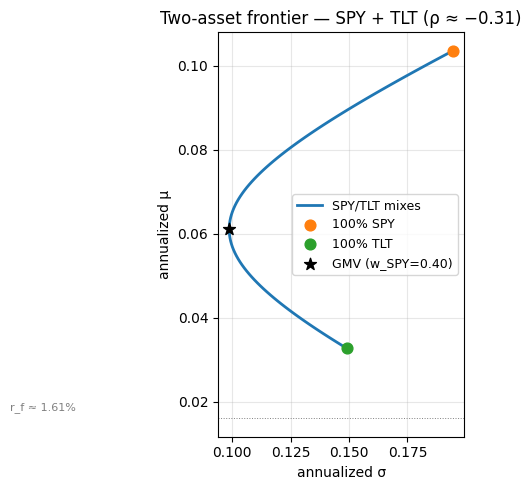

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sig_p, mu_p, color="C0", lw=2, label="SPY/TLT mixes")
ax.scatter([s_spy], [mu_spy], color="C1", s=60, zorder=5, label="100% SPY")
ax.scatter([s_tlt], [mu_tlt], color="C2", s=60, zorder=5, label="100% TLT")
ax.scatter([sig_gmv_2], [mu_gmv_2], color="black", s=80, marker="*", zorder=6,
           label=f"GMV (w_SPY={w_gmv_2:.2f})")
ax.axhline(rf_ann_avg, color="grey", lw=0.7, ls=":")
ax.text(0.005, rf_ann_avg + 0.002, f"r_f ≈ {rf_ann_avg:.2%}", fontsize=8, color="grey")
ax.set_xlabel("annualized σ")
ax.set_ylabel("annualized μ")
ax.set_title("Two-asset frontier — SPY + TLT (ρ ≈ −0.31)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Read this picture as the whole chapter in miniature.** The curve bows left because ρ < 1 (and especially because ρ < 0). The leftmost point is the GMV — the lowest-vol mix. The upper branch is the efficient frontier of this two-asset universe. Anywhere on the lower branch is dominated: same vol, less return.

The 8-asset case in §3 generalizes this picture — same shape (frontier + GMV + dominated branch), just in higher dimensions and solved numerically.

## 3. The efficient frontier — full 8-asset case

### 3.1 Restating the math

> *μ*<sub>p</sub> = **w**ᵀ**μ**     and     *σ*<sub>p</sub>² = **w**ᵀ**Σ****w**

with **w**ᵀ**1** = 1 (full investment) and *w*<sub>i</sub> ≥ 0 (long-only). We package these as small helper functions so every section reuses the same primitives.

In [6]:
ones = np.ones(K)
mu_vec = mu_raw.values         # use raw means as the body's primary input
Sigma_mat = Sigma.values

def port_mean(w, mu_=mu_vec):
    return float(w @ mu_)

def port_vol(w, S=Sigma_mat):
    return float(np.sqrt(w @ S @ w))

def port_sharpe(w, mu_=mu_vec, rf=rf_ann_avg, S=Sigma_mat):
    s = port_vol(w, S)
    return ((w @ mu_) - rf) / s if s > 0 else -np.inf

### 3.2 The Global Minimum Variance portfolio — analytic and long-only

Closed form (unconstrained):

> **w**<sub>GMV</sub> = **Σ**⁻¹**1** / (**1**ᵀ**Σ**⁻¹**1**)

— and a numerical version with the long-only constraint.

In [7]:
# Unconstrained analytic GMV
Sigma_inv = np.linalg.inv(Sigma_mat)
w_gmv_uncon = (Sigma_inv @ ones) / (ones @ Sigma_inv @ ones)

# Long-only GMV via SLSQP
cons_sum1 = {"type": "eq", "fun": lambda w: w.sum() - 1.0}
bounds_long = [(0.0, 1.0)] * K
w0 = ones / K
res_gmv = minimize(port_vol, w0, method="SLSQP",
                   constraints=[cons_sum1], bounds=bounds_long)
w_gmv = res_gmv.x

gmv_table = pd.DataFrame({
    "Unconstrained": w_gmv_uncon,
    "Long-only":     w_gmv,
}, index=TICKERS)
print(gmv_table.round(4))
print()
print(f"Unconstrained GMV: σ = {port_vol(w_gmv_uncon):.4%}, μ = {port_mean(w_gmv_uncon):.4%}")
print(f"Long-only     GMV: σ = {port_vol(w_gmv):.4%}, μ = {port_mean(w_gmv):.4%}")

     Unconstrained  Long-only
SPY         0.2371     0.1060
TLT         0.4516     0.4526
GLD         0.1629     0.1643
XLK        -0.0716     0.0000
XLF        -0.0039     0.0148
XLE        -0.0015     0.0082
XLV         0.2074     0.2263
XLU         0.0180     0.0278

Unconstrained GMV: σ = 8.9604%, μ = 6.4440%
Long-only     GMV: σ = 8.9750%, μ = 6.5930%


**Notice:** the unconstrained version shorts XLK by ~7%; the long-only version sets that to zero and reallocates. The vol cost of going long-only is essentially nil (8.96% → 8.98%). Both versions concentrate in TLT (low vol, negative ρ to equities), XLV (lowest-vol equity sector), and GLD (decorrelated from equities). **The optimizer doesn't know "broad market" — it just minimizes variance, and from a variance perspective SPY is dominated by lower-vol diversifiers.**

### 3.3 Tracing the frontier

For each target return, minimize variance subject to **w**ᵀ**μ** = *μ*<sub>target</sub>, **w**ᵀ**1** = 1, *w* ≥ 0.

In [8]:
mu_min, mu_max = mu_vec.min(), mu_vec.max()
targets = np.linspace(mu_min, mu_max, 50)

ef_sigmas, ef_mus, ef_ws = [], [], []
for tgt in targets:
    cons = [cons_sum1, {"type": "eq", "fun": lambda w, t=tgt: w @ mu_vec - t}]
    res = minimize(port_vol, w0, method="SLSQP", constraints=cons, bounds=bounds_long)
    if res.success:
        ef_sigmas.append(port_vol(res.x))
        ef_mus.append(port_mean(res.x))
        ef_ws.append(res.x)
ef_sigmas = np.array(ef_sigmas); ef_mus = np.array(ef_mus)
print(f"frontier points solved: {len(ef_sigmas)}")

frontier points solved: 50


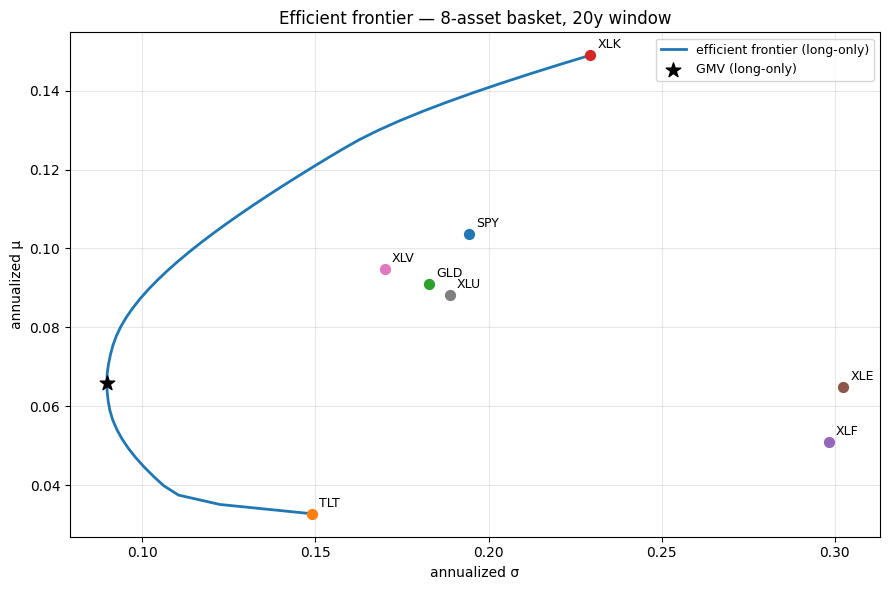

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ef_sigmas, ef_mus, color="C0", lw=2, label="efficient frontier (long-only)")

# individual assets
for i, t in enumerate(TICKERS):
    ax.scatter(np.sqrt(Sigma_mat[i,i]), mu_vec[i], s=50, zorder=5)
    ax.annotate(t, (np.sqrt(Sigma_mat[i,i]), mu_vec[i]), xytext=(5, 5),
                textcoords="offset points", fontsize=9)

# GMV markers
ax.scatter(port_vol(w_gmv), port_mean(w_gmv), s=120, marker="*", color="black",
           zorder=6, label="GMV (long-only)")

ax.set_xlabel("annualized σ"); ax.set_ylabel("annualized μ")
ax.set_title("Efficient frontier — 8-asset basket, 20y window")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Every individual asset sits inside the frontier** — that's the diversification-dominance fact from Ch3 made formal: you can always do better than holding any single name alone. The leftmost point is the GMV; the curve runs up and to the right from there, with the trade-off "more expected return ⇔ more vol" baked in.

## 4. The tangency portfolio — the max-Sharpe construction

### 4.1 Adding the risk-free asset

Mixing *r<sub>f</sub>* with a risky portfolio **w** traces a *straight line* in (σ, μ) space through (0, *r<sub>f</sub>*) and (σ<sub>w</sub>, μ<sub>w</sub>). The slope of that line is **w**'s Sharpe. The *steepest* such line picks the **tangency portfolio** — the point on the frontier where Sharpe is maximized.

### 4.2 Analytic + long-only

> **w**<sub>tan</sub> ∝ **Σ**⁻¹ (**μ** − *r<sub>f</sub>* **1**),   normalized to sum to 1.

> **Foot-gun:** Σ⁻¹ amplifies small differences in (μ − *r<sub>f</sub>*). This is the math behind §5's instability.

In [10]:
# Unconstrained analytic tangency
excess = mu_vec - rf_ann_avg
w_tan_uncon = Sigma_inv @ excess
w_tan_uncon = w_tan_uncon / w_tan_uncon.sum()

# Long-only tangency via SLSQP (minimize negative Sharpe)
def neg_sharpe(w): return -port_sharpe(w)
res_tan = minimize(neg_sharpe, w0, method="SLSQP",
                   constraints=[cons_sum1], bounds=bounds_long)
w_tan = res_tan.x

tan_table = pd.DataFrame({
    "Unconstrained": w_tan_uncon,
    "Long-only":     w_tan,
}, index=TICKERS)
print(tan_table.round(4))
print()
print(f"Unconstrained tangency: σ = {port_vol(w_tan_uncon):.4%}, μ = {port_mean(w_tan_uncon):.4%}, Sharpe = {port_sharpe(w_tan_uncon):.4f}")
print(f"Long-only     tangency: σ = {port_vol(w_tan):.4%}, μ = {port_mean(w_tan):.4%}, Sharpe = {port_sharpe(w_tan):.4f}")

     Unconstrained  Long-only
SPY        -0.1456     0.0000
TLT         0.1169     0.2288
GLD         0.3130     0.2880
XLK         0.6191     0.3412
XLF        -0.2440     0.0000
XLE        -0.1036     0.0000
XLV         0.3245     0.1416
XLU         0.1197     0.0004

Unconstrained tangency: σ = 13.8502%, μ = 13.1648%, Sharpe = 0.8346
Long-only     tangency: σ = 11.1999%, μ = 9.7986%, Sharpe = 0.7315


**SPY drops to zero in the long-only tangency.** The optimizer prefers XLK (higher μ at not-much-higher σ) for equity exposure, plus GLD/TLT/XLV as diversifiers. Half the basket gets zero weight (XLF, XLE, XLU squeezed out). The headline 0.73 in-sample Sharpe is +0.21 above 60/40 — *hold lightly*; §4.5 puts a CI on it and §5 shows the *weights* are wildly sample-dependent.

### 4.4 The Capital Market Line, drawn

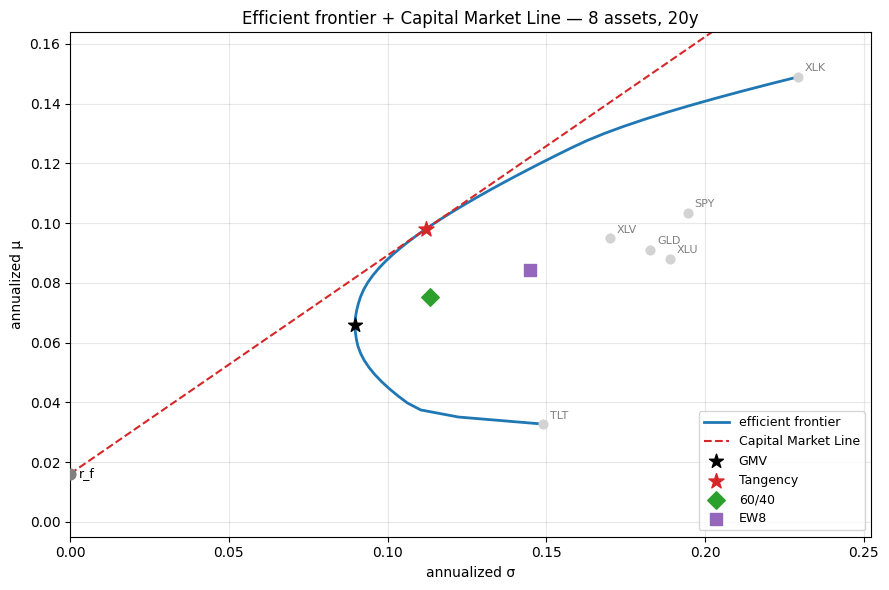

In [11]:
# Reference portfolios for comparison
w_ew8   = ones / K
w_60_40 = np.array([0.6 if t == "SPY" else 0.4 if t == "TLT" else 0.0 for t in TICKERS])

# Capital Market Line: from (0, r_f) through tangency, extended
sig_tan, mu_tan = port_vol(w_tan), port_mean(w_tan)
cml_x = np.linspace(0, max(ef_sigmas)*1.05, 100)
cml_y = rf_ann_avg + (mu_tan - rf_ann_avg) / sig_tan * cml_x

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(ef_sigmas, ef_mus, color="C0", lw=2, label="efficient frontier")
ax.plot(cml_x, cml_y, color="C3", lw=1.5, ls="--", label="Capital Market Line")

for i, t in enumerate(TICKERS):
    ax.scatter(np.sqrt(Sigma_mat[i,i]), mu_vec[i], s=40, color="lightgrey", zorder=4)
    ax.annotate(t, (np.sqrt(Sigma_mat[i,i]), mu_vec[i]), xytext=(5, 4),
                textcoords="offset points", fontsize=8, color="grey")

ax.scatter(port_vol(w_gmv),   port_mean(w_gmv),   s=110, marker="*", color="black",  zorder=6, label="GMV")
ax.scatter(sig_tan,           mu_tan,             s=130, marker="*", color="C3",     zorder=7, label="Tangency")
ax.scatter(port_vol(w_60_40), port_mean(w_60_40), s=80,  marker="D", color="C2",     zorder=6, label="60/40")
ax.scatter(port_vol(w_ew8),   port_mean(w_ew8),   s=80,  marker="s", color="C4",     zorder=6, label="EW8")
ax.scatter(0, rf_ann_avg, s=60, marker="o", color="grey", zorder=5)
ax.annotate("r_f", (0, rf_ann_avg), xytext=(6, -2), textcoords="offset points", fontsize=9)

ax.set_xlim(0, max(ef_sigmas)*1.1)
ax.set_ylim(min(0, rf_ann_avg)-0.005, max(ef_mus)*1.1)
ax.set_xlabel("annualized σ"); ax.set_ylabel("annualized μ")
ax.set_title("Efficient frontier + Capital Market Line — 8 assets, 20y")
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

The CML *just kisses* the frontier at the tangency point — and is everywhere above the frontier elsewhere. That's the geometric meaning of "best Sharpe": the steepest line you can draw from (0, *r<sub>f</sub>*) to anywhere achievable. The 60/40 and EW8 markers are visibly *below* the CML — they're not Sharpe-optimal in this in-sample picture.

### 4.5 Tangency Sharpe with a Ch5-style 95% CI

Per Ch5 §4.3: SE(Sharpe) ≈ SE(μ̂_excess)/σ; annualize ×√252; build the 95% CI as point ± 1.96·SE.

In [12]:
def realized_sharpe_with_ci(weights, log_returns, rf_daily):
    port_r  = log_returns @ weights
    excess  = port_r - rf_daily
    mu_e    = excess.mean()
    sigma   = port_r.std()
    sharpe_d = mu_e / sigma if sigma > 0 else 0.0
    sharpe_a = sharpe_d * np.sqrt(252)
    se_a    = (sigma / np.sqrt(len(excess))) / sigma * np.sqrt(252)  # = √252/√N
    return sharpe_a, sharpe_a - 1.96 * se_a, sharpe_a + 1.96 * se_a

rows = []
for name, w in [
    ("Tangency (LO)",     w_tan),
    ("60/40 SPY-TLT",     w_60_40),
    ("EW8",               w_ew8),
    ("GMV (LO)",          w_gmv),
]:
    s, lo, hi = realized_sharpe_with_ci(w, log_returns, rf_daily)
    rows.append({"portfolio": name, "Sharpe": s, "95% CI low": lo, "95% CI high": hi,
                 "vol": port_vol(w), "mean": port_mean(w)})
pd.DataFrame(rows).round(4)

,portfolio,Sharpe,95% CI low,95% CI high,vol,mean
0,Tangency (LO),0.7315,0.2928,1.1702,0.1120,0.0980
1,60/40 SPY-TLT,0.5213,0.0826,0.9600,0.1134,0.0752
2,EW8,0.4711,0.0324,0.9098,0.1450,0.0844
3,GMV (LO),0.5556,0.1169,0.9944,0.0897,0.0659


**Read the CIs side-by-side.** The tangency CI is comfortably overlapping with 60/40's. At 20-year sample sizes we **cannot reject** "tangency and 60/40 have the same true Sharpe" at the 5% level — the headline +0.21 gain may not be statistically real. This is Ch4's noise lesson, transmitted through Ch5's Sharpe-CI machinery, into Ch6's optimization output.

## 5. The instability problem — why MVO is hard

### 5.1 Why the tangency formula is brittle

Two facts: (a) Σ⁻¹ has large *cancelling* off-diagonal entries when assets are highly correlated; (b) μ̂ is noisy (Ch4). Multiply a noisy vector by a matrix with cancelling large entries → noisy weights.

### 5.2 Bootstrap demonstration

Block-bootstrap the daily-returns panel (length-21 blocks to preserve some clustering — naive iid bootstrap would smear it out), 200 times. Each resample: recompute μ̂, Σ̂, refit long-only tangency. Plot the distribution of weights.

In [13]:
def block_bootstrap_indices(n, block_len, rng):
    n_blocks = int(np.ceil(n / block_len))
    starts = rng.integers(0, n - block_len + 1, size=n_blocks)
    idx = np.concatenate([np.arange(s, s + block_len) for s in starts])
    return idx[:n]

rng = np.random.default_rng(42)
n_boot = 200
block_len = 21
boot_weights = np.zeros((n_boot, K))
boot_sharpes = np.zeros(n_boot)

for b in range(n_boot):
    idx = block_bootstrap_indices(N, block_len, rng)
    sample = log_returns.values[idx]
    mu_b = sample.mean(axis=0) * 252
    Sig_b = np.cov(sample, rowvar=False) * 252

    def neg_sharpe_b(w, mu_=mu_b, S=Sig_b, rf=rf_ann_avg):
        s = float(np.sqrt(w @ S @ w))
        return -((w @ mu_ - rf) / s) if s > 0 else 1e6

    res = minimize(neg_sharpe_b, w0, method="SLSQP",
                   constraints=[cons_sum1], bounds=bounds_long)
    if res.success:
        boot_weights[b] = res.x
        boot_sharpes[b] = -res.fun

boot_df = pd.DataFrame(boot_weights, columns=TICKERS)
summary = pd.DataFrame({
    "in-sample weight": w_tan,
    "bootstrap mean":   boot_df.mean().values,
    "stdev":            boot_df.std().values,
    "min":              boot_df.min().values,
    "max":              boot_df.max().values,
}, index=TICKERS)
print(summary.round(3))

     in-sample weight  bootstrap mean  stdev    min    max
SPY            0.0000          0.0080 0.0530 0.0000 0.5150
TLT            0.2290          0.2070 0.1260 0.0000 0.5250
GLD            0.2880          0.2720 0.1630 0.0000 0.7590
XLK            0.3410          0.2960 0.1870 0.0000 1.0000
XLF            0.0000          0.0000 0.0030 0.0000 0.0380
XLE            0.0000          0.0060 0.0290 0.0000 0.2770
XLV            0.1420          0.1330 0.1700 0.0000 0.8370
XLU            0.0000          0.0760 0.1120 0.0000 0.5000


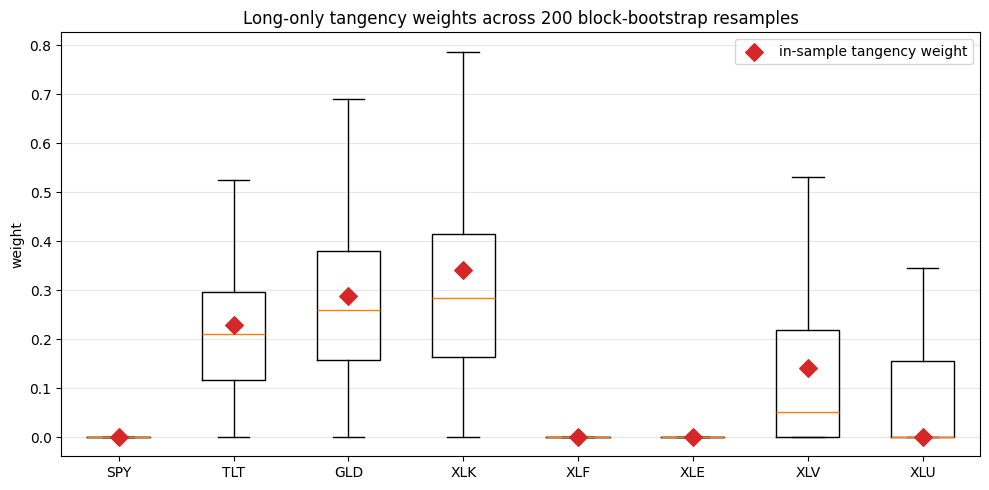

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(K)
ax.boxplot([boot_df[t].values for t in TICKERS], positions=positions,
           widths=0.55, showfliers=False)
ax.scatter(positions, w_tan, s=80, color="C3", marker="D", zorder=5,
           label="in-sample tangency weight")
ax.set_xticks(positions); ax.set_xticklabels(TICKERS)
ax.set_ylabel("weight")
ax.set_title("Long-only tangency weights across 200 block-bootstrap resamples")
ax.grid(axis="y", alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

**XLK alone moves between 0% and 100% across resamples of essentially the same data** — there are individual bootstrap draws on which the "optimal" portfolio is *entirely* XLK. That's the entire instability story in one boxplot: the optimizer's answer to "how much tech?" is sample-dependent in the extreme. The same data 20× over would land you on different "optimal" portfolios.

Three remediations (one paragraph each in the README): shrink μ̂ (Ch4 — mild at this N), shrink Σ̂ (Ledoit-Wolf, deferred), constrain the optimizer (long-only already helped, plus per-asset caps). Risk parity (§6) goes further — drop μ̂ from the inputs altogether.

## 6. Risk parity — the practitioner's pivot

### 6.1 Risk contribution

> *MRC*<sub>i</sub> = (**Σ****w**)<sub>i</sub> / *σ*<sub>p</sub>     (marginal — partial derivative of σ_p w.r.t. w_i)
>
> *RC*<sub>i</sub> = *w*<sub>i</sub> · *MRC*<sub>i</sub>          (risk contribution — RCs sum to *σ*<sub>p</sub>)

### 6.2 Audit: EW8 risk contributions

Naive equal-weight does *not* equally allocate risk. Compute the RCs for EW8 to see exactly how lopsided it is.

In [15]:
def risk_contributions(w, S=Sigma_mat):
    sigma_p = float(np.sqrt(w @ S @ w))
    mrc = S @ w / sigma_p
    return w * mrc, sigma_p   # (RC vector, total σ_p)

rc_ew, sig_ew = risk_contributions(w_ew8)
rc_table = pd.DataFrame({
    "weight":         w_ew8,
    "RC (decimal)":   rc_ew,
    "RC fraction":    rc_ew / sig_ew,
}, index=TICKERS)
print(f"EW8 portfolio σ_p = {sig_ew:.4%}\n")
print(rc_table.round(4))

EW8 portfolio σ_p = 14.4972%

     weight  RC (decimal)  RC fraction
SPY  0.1250        0.0230       0.1589
TLT  0.1250       -0.0031      -0.0214
GLD  0.1250        0.0058       0.0399
XLK  0.1250        0.0239       0.1651
XLF  0.1250        0.0309       0.2130
XLE  0.1250        0.0303       0.2093
XLV  0.1250        0.0168       0.1162
XLU  0.1250        0.0173       0.1192


**XLF and XLE — the two highest-vol sectors — together carry ~42% of EW8's risk on 25% of the weight.** TLT *removes* risk (negative RC) thanks to its negative correlation with equities. Equal capital weight ≠ equal risk weight.

### 6.3 Solving for ERC

Minimize the squared dispersion of risk contributions:

> minimize Σ<sub>i</sub> (*RC*<sub>i</sub> − *σ*<sub>p</sub>/K)²    s.t.    **w**ᵀ**1** = 1, *w* > 0

In [16]:
def erc_objective(w, S=Sigma_mat, K_=K):
    sig = float(np.sqrt(w @ S @ w))
    rc = w * (S @ w) / sig
    target = sig / K_
    return float(np.sum((rc - target)**2))

bounds_pos = [(1e-6, 1.0)] * K
res_rp = minimize(erc_objective, w0, method="SLSQP",
                  constraints=[cons_sum1], bounds=bounds_pos)
w_rp = res_rp.x

rc_rp, sig_rp = risk_contributions(w_rp)
rp_table = pd.DataFrame({
    "weight":      w_rp,
    "RC fraction": rc_rp / sig_rp,
}, index=TICKERS)
print(f"RP portfolio σ_p = {sig_rp:.4%}")
print(f"target equal share = 1/K = {1/K:.4f}\n")
print(rp_table.round(4))

RP portfolio σ_p = 10.0914%
target equal share = 1/K = 0.1250

     weight  RC fraction
SPY  0.0859       0.1272
TLT  0.3357       0.1272
GLD  0.1613       0.1295
XLK  0.0803       0.1254
XLF  0.0640       0.1168
XLE  0.0696       0.1305
XLV  0.1077       0.1217
XLU  0.0955       0.1217


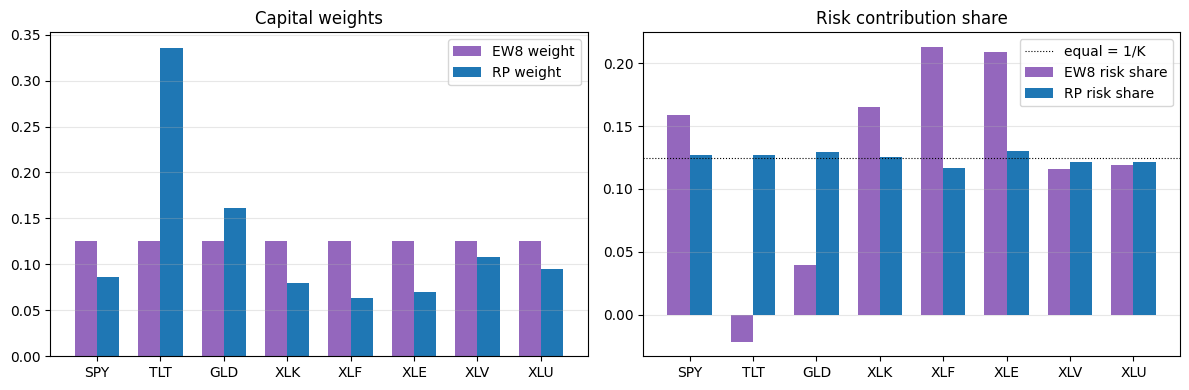

In [17]:
# Side-by-side comparison: EW8 vs RP weights and risk shares
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(K)
width = 0.35
ax1.bar(x - width/2, w_ew8, width, label="EW8 weight", color="C4")
ax1.bar(x + width/2, w_rp,  width, label="RP weight",  color="C0")
ax1.set_xticks(x); ax1.set_xticklabels(TICKERS); ax1.set_title("Capital weights")
ax1.legend(); ax1.grid(axis="y", alpha=0.3)

ax2.bar(x - width/2, rc_ew / sig_ew, width, label="EW8 risk share", color="C4")
ax2.bar(x + width/2, rc_rp / sig_rp, width, label="RP risk share",  color="C0")
ax2.axhline(1/K, color="black", lw=0.8, ls=":", label=f"equal = 1/K")
ax2.set_xticks(x); ax2.set_xticklabels(TICKERS); ax2.set_title("Risk contribution share")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()

**TLT goes from 12.5% capital share (EW8) to 34% (RP)** — risk parity loads up on the low-vol, negatively-correlated bond exposure because its *risk* contribution is small at any given weight. **XLF and XLE shrink** from 12.5% to ~6–7% to bring their risk contributions down to the equal share. Right panel: every RP bar lands on the dotted "1/K" line; EW8 bars are wildly unequal.

### 6.4 Final comparison — six portfolios on one row

In [18]:
rows = []
for name, w in [
    ("60/40",          w_60_40),
    ("EW8",            w_ew8),
    ("GMV (LO)",       w_gmv),
    ("Tangency (LO)",  w_tan),
    ("Risk Parity",    w_rp),
]:
    s, lo, hi = realized_sharpe_with_ci(w, log_returns, rf_daily)
    rows.append({
        "portfolio": name,
        "σ_ann":  port_vol(w),
        "μ_ann":  port_mean(w),
        "Sharpe": s,
        "CI low": lo,
        "CI high": hi,
    })
pd.DataFrame(rows).round(4)

,portfolio,σ_ann,μ_ann,Sharpe,CI low,CI high
0,60/40,0.1134,0.0752,0.5213,0.0826,0.9600
1,EW8,0.1450,0.0844,0.4711,0.0324,0.9098
2,GMV (LO),0.0897,0.0659,0.5556,0.1169,0.9944
3,Tangency (LO),0.1120,0.0980,0.7315,0.2928,1.1702
4,Risk Parity,0.1009,0.0729,0.5633,0.1246,1.0020


**Reading the table:**

- **GMV** has the lowest vol (8.98%) — by construction.
- **Tangency** has the highest in-sample Sharpe (0.73) — by construction; *but* its CI overlaps everything except TLT's.
- **Risk Parity** lands a Sharpe of 0.56 with vol around 10% — a touch above 60/40 at lower vol, *and* with eight diversified exposures rather than two, **with no μ̂ input.**
- **EW8** is the clear underperformer — same broad equity tilt as the others, but distributed in a way that loads risk into XLF/XLE.

The §5 caveat applies to every Sharpe in this table: the CIs are wide enough that ranking by point Sharpe is not statistically robust at 20 years. Don't make a hiring decision on these numbers; do use them to choose a *philosophy*.

## 7. What we just learned

Three philosophies, three sections:

- **GMV** — depends on Σ only. Minimum vol. Concentrates in low-vol diversifiers.
- **Tangency** — depends on μ, Σ, *r<sub>f</sub>*. Max Sharpe. **Wildly unstable across bootstrap resamples** — XLK weight ranges from 0% to 100% on essentially the same data.
- **Risk parity** — depends on Σ only. Equal risk shares by construction. Comparable Sharpe to 60/40, lower vol, eight diversified exposures, *no μ input*.

Hidden lesson: **estimation error.** MVO's optimizer is doing exactly what it was asked to do — and what it was asked to do amplifies the noise in μ̂ via Σ⁻¹. Three remedies in practice (shrink μ̂, shrink Σ̂, constrain the search), and one alternative philosophy (risk parity) that sidesteps the μ̂ problem entirely.

*The exercises follow below; the chapter README has the §8 So-What? section and full Key Terms table.*

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **Two-asset frontier with a different correlation.** Repeat §2 with **SPY and GLD** instead of SPY and TLT. SPY/GLD's correlation is closer to zero than SPY/TLT's negative. How much less does the curve "bow" in (σ, μ) space? Compute the two-asset GMV vol for SPY/GLD and compare to SPY/TLT. What does the comparison say about *negative* correlation as a diversification tool versus merely *low* correlation?

2. **Frontier with raw vs JS-shrunk means.** Re-trace the §3.3 frontier using **JS-shrunk means** (`mu_js`, already built in §1) in place of raw means. Plot both frontiers on the same axes. Does the tangency portfolio's composition (§4.3) change? Hint: at this sample size the shrinkage is mild, so the difference will be subtle — the *exercise* is to confirm that with your own eyes and reflect on when shrinkage would matter more (smaller N, broader cross-section, or both).

3. **Risk parity without TLT.** Drop TLT from the basket and recompute risk parity on the remaining seven assets. How do the weights and the total vol change? Which asset takes the largest share of TLT's old role? What does this exercise tell you about the role of *negative-correlation* assets in risk-parity portfolios specifically (versus low-correlation ones)?

4. *(stretch)* **Out-of-sample test of tangency.** Split the 20y window in half. Fit the long-only tangency portfolio on the **first 10y only**; **freeze those weights**, then compute the realized Sharpe on the **second 10y**. Compare to (a) the 60/40 portfolio and (b) the risk-parity portfolio on the same hold-out window. Was the in-sample 0.73 Sharpe gain real out-of-sample, or did it shrink? *This is the single most important sanity check for any optimization-based approach, and the warm-up for Chapter 13.*

*End of notebook. The chapter README has the full prose, So-What? section, and Key Terms table.*

## Exercises

Try these in fresh cells below. Solutions are not provided — the goal is to consolidate the chapter's machinery on slightly different inputs.

1. **Two-asset frontier with a different correlation.** Repeat §2 with **SPY and GLD** instead of SPY and TLT. SPY/GLD's correlation is closer to zero than SPY/TLT's negative. How much less does the curve "bow" in (σ, μ) space? Compute the two-asset GMV vol for SPY/GLD and compare to SPY/TLT. What does the comparison say about *negative* correlation as a diversification tool versus merely *low* correlation?

2. **Frontier with raw vs JS-shrunk means.** Re-trace the §3.3 frontier using **JS-shrunk means** in place of raw means. Plot both frontiers on the same axes. Does the tangency portfolio's composition (§4.3) change? Hint: at this sample size the shrinkage is mild, so the difference will be subtle — the *exercise* is to confirm that with your own eyes and reflect on when shrinkage would matter more (smaller N, broader cross-section, or both).

3. **Risk parity without TLT.** Drop TLT from the basket and recompute risk parity on the remaining seven assets. How do the weights and the total vol change? Which asset takes the largest share of TLT's old role? What does this exercise tell you about the role of *negative-correlation* assets in risk-parity portfolios specifically (versus low-correlation ones)?

4. *(stretch)* **Out-of-sample test of tangency.** Split the 20y window in half. Fit the long-only tangency portfolio on the **first 10y only**; **freeze those weights**, then compute the realized Sharpe on the **second 10y**. Compare to (a) the 60/40 portfolio and (b) the risk-parity portfolio on the same hold-out window. Was the in-sample 0.73 Sharpe gain real out-of-sample, or did it shrink? *This is the single most important sanity check for any optimization-based approach, and the warm-up for Chapter 13.*
